# SPECSENSE: DECODING THE HIDDEN PRICE LOGIC OF SMARTPHONES

**Problem Statement:** Can a smartphone's price be predicted purely from its
hardware specifications, and do these specifications naturally group phones
into real market segments (budget, mid-range, flagship) — without ever
knowing the price?

**Input:** Brand, Ratings, RAM, ROM, and other hardware specifications

**Output:** Price

1.IMPORT

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

2.LOADING THE DATASET

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Mobile Price Prediction Datatset.csv to Mobile Price Prediction Datatset.csv


In [ ]:
df=pd.read_csv("Mobile Price Prediction Datatset.csv")

In [ ]:
df.head()

,Unnamed: 0,Brand me,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,0,"LG V30+ (Black, 128 )",4.3,4.0,128.0,6.00,48,13.0,4000,24999
1,1,I Kall K11,3.4,6.0,64.0,4.50,48,12.0,4000,15999
2,2,Nokia 105 ss,4.3,4.0,4.0,4.50,64,16.0,4000,15000
3,3,"Samsung Galaxy A50 (White, 64 )",4.4,6.0,64.0,6.40,48,15.0,3800,18999
4,4,"POCO F1 (Steel Blue, 128 )",4.5,6.0,128.0,6.18,35,15.0,3800,18999


In [ ]:
target_candidates = [c for c in df.columns if "price" in c.lower()]
print("Detected possible target column(s):", target_candidates)
TARGET = target_candidates[0] if target_candidates else df.columns[-1]
print("Using target:", TARGET)

Detected possible target column(s): ['Price']
Using target: Price


3.EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836 entries, 0 to 835
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     836 non-null    int64  
 1   Brand me       836 non-null    object 
 2   Ratings        805 non-null    float64
 3   RAM            829 non-null    float64
 4   ROM            832 non-null    float64
 5   Mobile_Size    834 non-null    float64
 6   Primary_Cam    836 non-null    int64  
 7   Selfi_Cam      567 non-null    float64
 8   Battery_Power  836 non-null    int64  
 9   Price          836 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 65.4+ KB


In [ ]:
df.describe()

,Unnamed: 0,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
count,836.000000,805.000000,829.000000,832.000000,834.000000,836.000000,567.000000,836.000000,836.00000
mean,417.500000,4.103106,6.066345,64.373077,5.597282,47.983254,9.784832,3274.688995,18220.34689
std,241.476707,0.365356,2.530336,53.447825,3.898664,11.170093,6.503838,927.518852,52805.55022
min,0.000000,2.800000,0.000000,0.000000,2.000000,5.000000,0.000000,1020.000000,479.00000
25%,208.750000,3.800000,6.000000,32.000000,4.500000,48.000000,5.000000,3000.000000,984.75000
50%,417.500000,4.100000,6.000000,40.000000,4.770000,48.000000,8.000000,3000.000000,1697.00000
75%,626.250000,4.400000,6.000000,64.000000,6.300000,48.000000,13.000000,3800.000000,18999.00000
max,835.000000,4.800000,34.000000,256.000000,44.000000,64.000000,61.000000,6000.000000,573000.00000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Brand me,0
Ratings,0
RAM,0
ROM,0
Mobile_Size,0
Primary_Cam,0
Selfi_Cam,0
Battery_Power,0
Price,0


In [ ]:
# Fill missing values using median

df['Ratings'].fillna(df['Ratings'].median(), inplace=True)
df['RAM'].fillna(df['RAM'].median(), inplace=True)
df['ROM'].fillna(df['ROM'].median(), inplace=True)
df['Mobile_Size'].fillna(df['Mobile_Size'].median(), inplace=True)
df['Selfi_Cam'].fillna(df['Selfi_Cam'].median(), inplace=True)

/tmp/ipykernel_753/1912193057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Ratings'].fillna(df['Ratings'].median(), inplace=True)
/tmp/ipykernel_753/1912193057.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df['Brand me'].value_counts()

,count
Brand me,
Kechaoda A27,11
Lava 34,8
Jivi R21Plus,8
Easyfone Star,8
MTR Ferrari,7
...,...
I Kall K24 New Coo of Two Mobiles,1
"Huawei Y9 Prime 2019 (Sapphire Blue, 128 )",1
ITEL magic 1 max,1


In [ ]:
print(df.dtypes)

Unnamed: 0         int64
Brand me          object
Ratings          float64
RAM              float64
ROM              float64
Mobile_Size      float64
Primary_Cam        int64
Selfi_Cam        float64
Battery_Power      int64
Price              int64
dtype: object


In [ ]:
df.nunique

<bound method DataFrame.nunique of      Unnamed: 0                         Brand me  Ratings   RAM    ROM  \
0             0            LG V30+ (Black, 128 )      4.3   4.0  128.0   
1             1                       I Kall K11      3.4   6.0   64.0   
2             2                     Nokia 105 ss      4.3   4.0    4.0   
3             3  Samsung Galaxy A50 (White, 64 )      4.4   6.0   64.0   
4             4       POCO F1 (Steel Blue, 128 )      4.5   6.0  128.0   
..          ...                              ...      ...   ...    ...   
831         831             Karbonn K24 Plus Pro      3.8   6.0   32.0   
832         832                  InFocus POWER 2      4.1   8.0   64.0   
833         833  Alcatel 5V (Spectrum Blue, 32 )      4.4   3.0   32.0   
834         834                      JIVI JV 12M      3.7  10.0   32.0   
835         835                  Blacear B5 Grip      3.5   6.0   32.0   

     Mobile_Size  Primary_Cam  Selfi_Cam  Battery_Power  Price  
0           6.00           48       13.0           4000  24999  
1           4.50           48       12.0           4000  15999  
2           4.50           64       16.0           4000  15000  
3           6.40           48       15.0           3800  18999  
4           6.18           35       15.0           3800  18999  
..           ...          ...        ...            ...    ...  
831         4.54           48       12.0           2800   1299  
832         4.54           64        8.0           2500   1390  
833         6.20           48        1.0           3800   9790  
834         4.50           64        8.0           3500    799  
835         4.50           64       15.0           1050    799  

[836 rows x 10 columns]>

In [ ]:
df['Price'].describe()

,Price
count,836.00000
mean,18220.34689
std,52805.55022
min,479.00000
25%,984.75000
50%,1697.00000
75%,18999.00000
max,573000.00000


In [ ]:
df.groupby('Brand me')['Price'].mean().sort_values(ascending=False).head(10)

,Price
Brand me,
"Apple iPhone XR (Yellow, 128 )",573000.0
"Apple iPhone XR ((PRODUCT)RED, 128 )",573000.0
"Apple iPhone XR (Coral, 128 )",573000.0
"Samsung Galaxy S10 (Prism White, 512 )",563000.0
"Redmi Note 8 (Cosmic Purple, 128 )",153000.0
"Apple iPhone 11 Pro (Space Grey, 512 )",140300.0
"Apple iPhone 11 Pro (Silver, 512 )",140300.0
"Apple iPhone 11 Pro (Space Grey, 256 )",121300.0
"Apple iPhone 11 Pro Max (Silver, 64 )",117100.0


In [ ]:
df.groupby('RAM')['Price'].mean()

,Price
RAM,
0.0,772.000000
1.0,2517.750000
2.0,9007.904762
3.0,14514.225000
4.0,12262.725664
5.0,1024.000000
6.0,6390.235698
8.0,44919.860759
10.0,12016.285714


In [ ]:
df.groupby('ROM')['Price'].mean()

,Price
ROM,
0.0,799.000000
2.0,2025.000000
2.4,1190.000000
3.0,1182.333333
4.0,2685.600000
8.0,3892.666667
10.0,920.000000
12.0,1579.000000
15.0,899.000000


In [ ]:
df[['Ratings','Price']].corr()

,Ratings,Price
Ratings,1.000000,0.366436
Price,0.366436,1.000000


In [ ]:
df.groupby('Battery_Power')['Price'].mean().head()

,Price
Battery_Power,
1020,2055.000000
1050,834.263158
1080,649.000000
1100,685.000000
1200,2090.294118


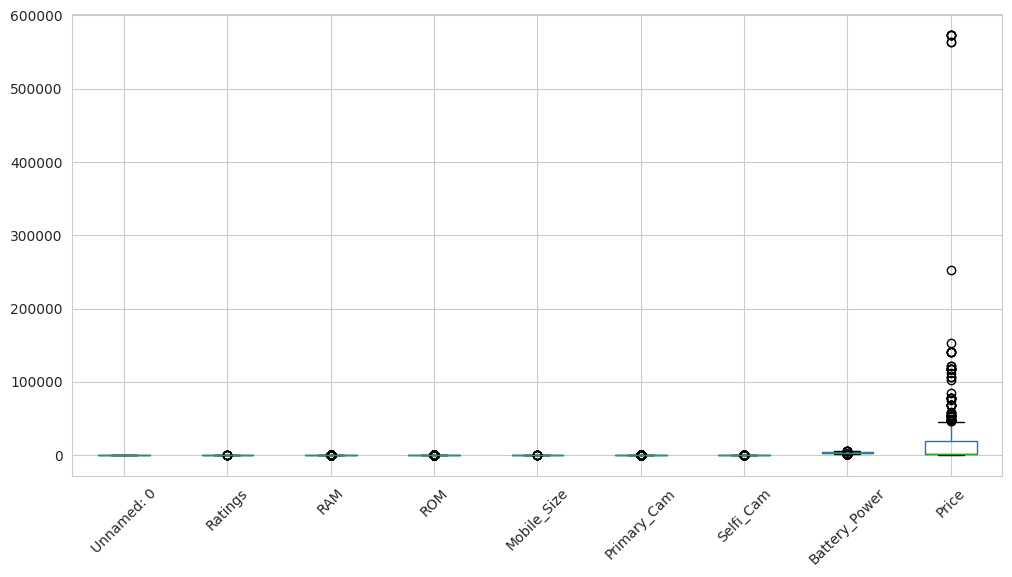

In [ ]:


df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

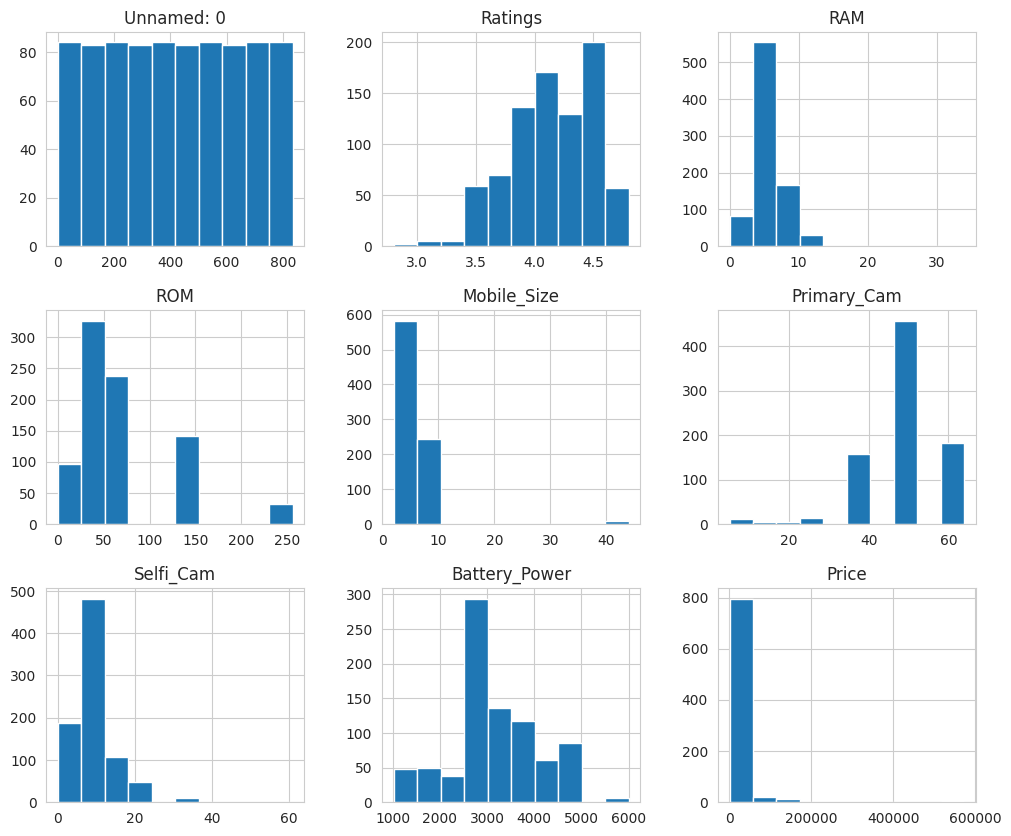

In [ ]:
df.hist(figsize=(12,10))
plt.show()

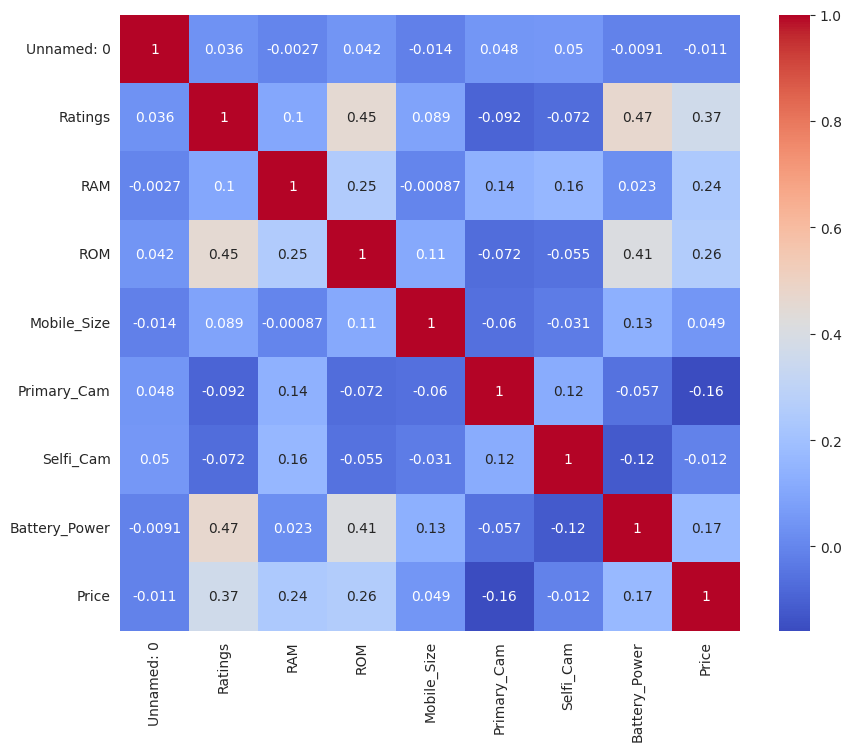

In [ ]:


plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

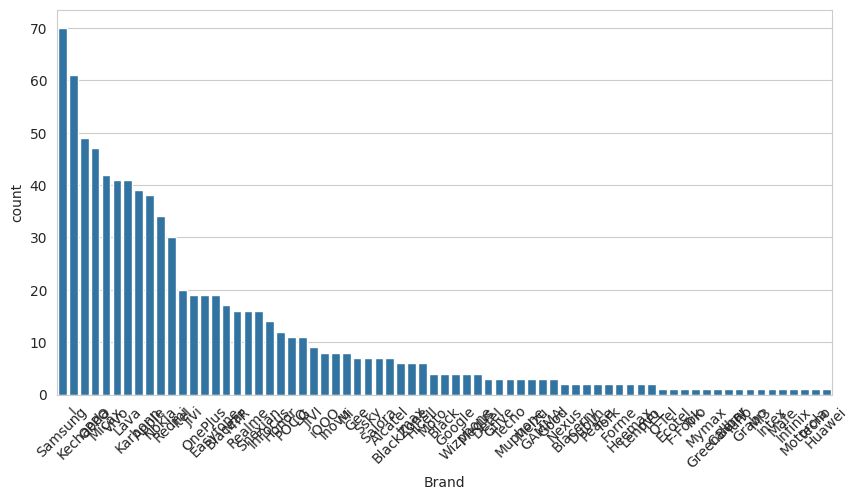

In [ ]:
df['Brand'] = df['Brand me'].str.split().str[0]

plt.figure(figsize=(10,5))
sns.countplot(x='Brand', data=df, order=df['Brand'].value_counts().index)
plt.xticks(rotation=45)
plt.show()

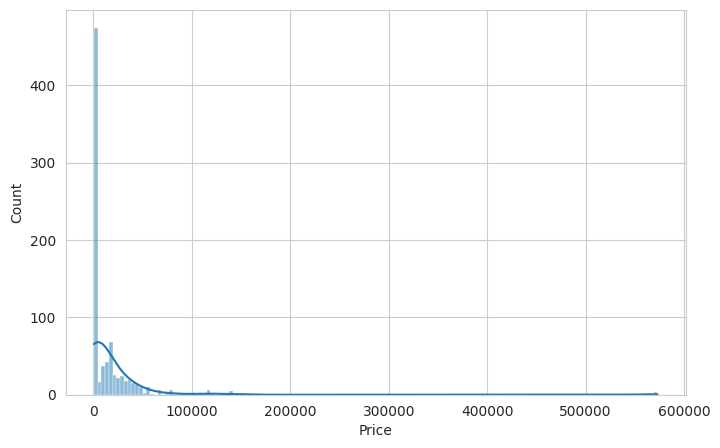

In [ ]:
sns.histplot(df['Price'],kde=True)
plt.show()

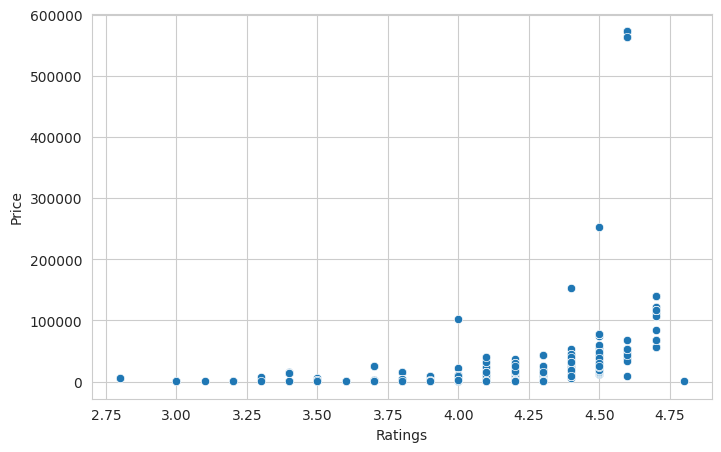

In [ ]:
sns.scatterplot(x='Ratings',y='Price',data=df)
plt.show()

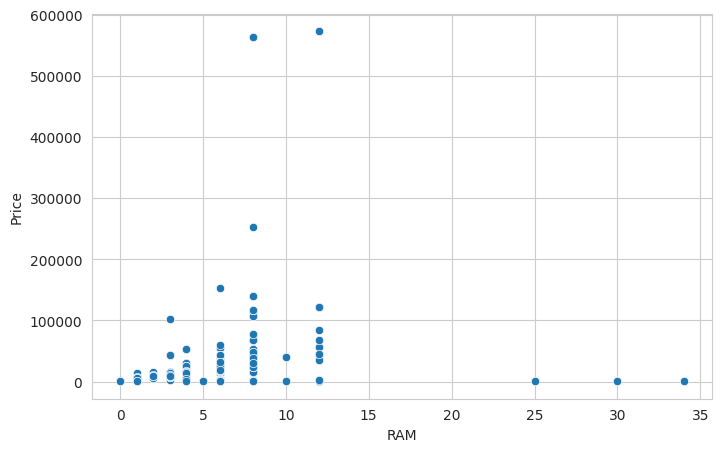

In [ ]:
sns.scatterplot(x='RAM',y='Price',data=df)
plt.show()

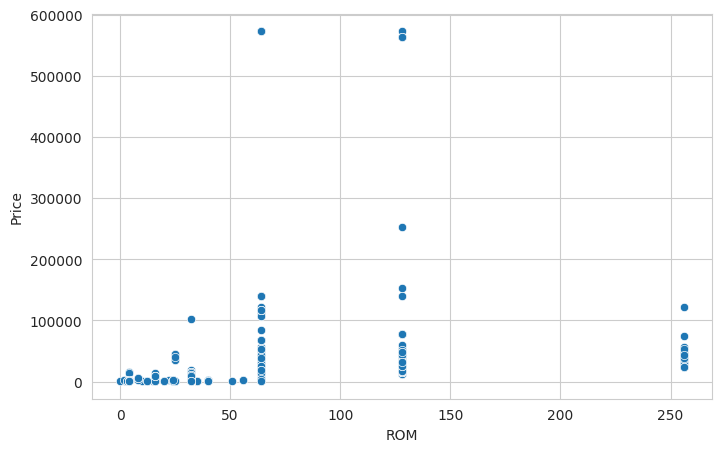

In [ ]:
sns.scatterplot(x='ROM',y='Price',data=df)
plt.show()

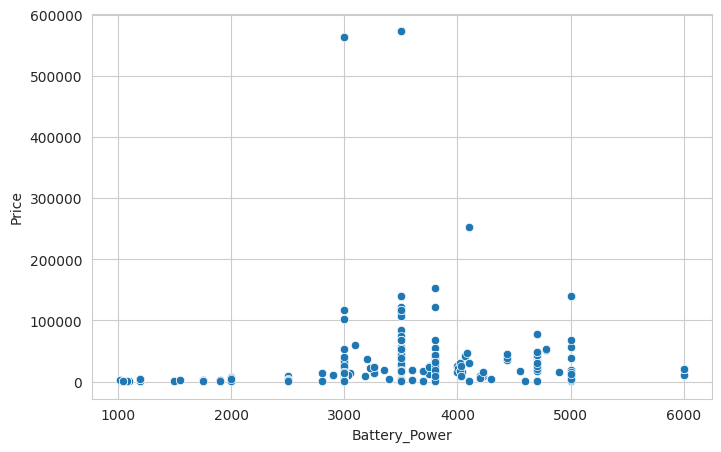

In [ ]:
sns.scatterplot(x='Battery_Power',y='Price',data=df)
plt.show()

PREPROCESSING

4.LABEL ENCODING

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Brand me'] = le.fit_transform(df['Brand me'])

In [ ]:
print(df['Brand me'].head())

0    184
1     82
2    250
3    349
4    303
Name: Brand me, dtype: int64


5.FEATURE SELECTION

In [ ]:
X = df.drop(['Price', 'Brand'], axis=1)
y = df['Price']

In [ ]:
print(X.head())
print(y.head())

   Unnamed: 0  Brand me  Ratings  RAM    ROM  Mobile_Size  Primary_Cam  \
0           0       184      4.3  4.0  128.0         6.00           48   
1           1        82      3.4  6.0   64.0         4.50           48   
2           2       250      4.3  4.0    4.0         4.50           64   
3           3       349      4.4  6.0   64.0         6.40           48   
4           4       303      4.5  6.0  128.0         6.18           35   

   Selfi_Cam  Battery_Power    Brand  
0       13.0           4000       LG  
1       12.0           4000        I  
2       16.0           4000    Nokia  
3       15.0           3800  Samsung  
4       15.0           3800     POCO  
0    24999
1    15999
2    15000
3    18999
4    18999
Name: Price, dtype: int64


In [ ]:
print(X.shape)
print(y.shape)

(836, 10)
(836,)


6.TRAIN-TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(668, 10)
(168, 10)
(668,)
(168,)


7.FEATURE SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Drop the 'Brand' column from X_train and X_test before scaling
X_train = X_train.drop('Brand', axis=1)
X_test = X_test.drop('Brand', axis=1)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print(X_train[:5])
print(X_test[:5])

[[-0.28411438  0.18087425 -0.57546218 -0.01914729 -0.60988881 -0.21907201
   0.03396298 -0.74601832 -0.49986233]
 [ 0.20062603  0.05657825 -0.02035931 -1.14771102 -0.60988881 -0.06363856
  -0.84199333 -0.74601832 -0.28548203]
 [ 1.15757047 -0.33288255 -0.02035931 -0.01914729 -0.60988881 -0.48306217
   1.43549307  2.32013589  0.25046872]
 [-0.46798144 -0.33288255 -0.02035931 -0.01914729 -0.60988881 -0.48306217
   1.43549307 -0.20493229  0.25046872]
 [ 1.45844383  1.31611103  1.08984643  0.73322853  1.28117345  0.25709714
   0.03396298  0.51651576  1.53675051]]
[[ 0.82326674  1.79672222  0.812295    0.73322853  3.80258978  0.19295
   0.03396298  0.69687778  1.25805612]
 [ 1.70917163 -0.18372735 -0.29791075 -0.01914729 -0.60988881 -0.27581756
   1.43549307 -0.20493229 -0.82143278]
 [-0.518127    0.79406784  1.08984643 -0.01914729  1.28117345  0.12880286
  -1.10478022 -0.74601832  0.57203917]
 [ 1.61723811  0.33002944  0.25719212 -0.77152311 -1.16144863 -0.28568635
   1.43549307  0.6968777

8.REGRESSION MODELS

In [ ]:
results = {}

def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    results[name] = {"R2": r2, "RMSE": rmse, "MAE": mae}
    print(f"{name:22s} | R2: {r2:.3f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}")

linear regression

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
pred = lin_reg.predict(X_test)
evaluate("Linear Regression", y_test, pred)

Linear Regression      | R2: 0.165 | RMSE: 44051.76 | MAE: 15691.00


polynomial regression

In [ ]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
pred = poly_reg.predict(X_test_poly)
evaluate("Polynomial Regression", y_test, pred)

Polynomial Regression  | R2: -0.010 | RMSE: 48447.58 | MAE: 18707.15


decision tree regression

In [ ]:
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)
pred = dt_reg.predict(X_test)
evaluate("Decision Tree", y_test, pred)

Decision Tree          | R2: 0.889 | RMSE: 16049.07 | MAE: 2817.53


random forest regressor

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)
pred = rf_reg.predict(X_test)
evaluate("Random Forest", y_test, pred)

Random Forest          | R2: 0.825 | RMSE: 20164.83 | MAE: 4118.52


gradient boosting regression

In [ ]:
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train, y_train)
pred = gb_reg.predict(X_test)
evaluate("Gradient Boosting", y_test, pred)

Gradient Boosting      | R2: 0.941 | RMSE: 11724.38 | MAE: 4418.88


KNeighbors Regression




In [ ]:
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)
pred = knn_reg.predict(X_test)
evaluate("KNN Regressor", y_test, pred)

KNN Regressor          | R2: 0.158 | RMSE: 44254.59 | MAE: 9676.56


9.MODEL COMPARISON

                             R2          RMSE           MAE
Gradient Boosting      0.940876  11724.384279   4418.878767
Decision Tree          0.889215  16049.074952   2817.529762
Random Forest          0.825107  20164.831597   4118.522381
Linear Regression      0.165342  44051.762197  15690.996984
KNN Regressor          0.157638  44254.589113   9676.564286
Polynomial Regression -0.009546  48447.579880  18707.153692


/tmp/ipykernel_753/3383649294.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df["R2"], palette="viridis")


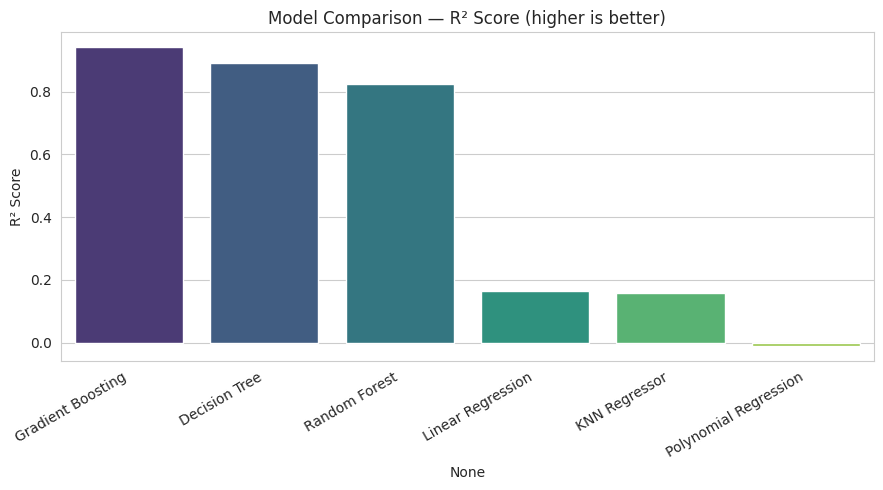

In [ ]:
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
print(results_df)

plt.figure(figsize=(9, 5))
sns.barplot(x=results_df.index, y=results_df["R2"], palette="viridis")
plt.xticks(rotation=30, ha="right")
plt.ylabel("R² Score")
plt.title("Model Comparison — R² Score (higher is better)")
plt.tight_layout()
plt.show()

10.HYPERPARAMETER TUNING

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
                     cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_model = grid.best_estimator_
pred = best_model.predict(X_test)
evaluate("Random Forest (Tuned)", y_test, pred)

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Random Forest (Tuned)  | R2: 0.814 | RMSE: 20800.73 | MAE: 4114.85


11.UNSUPERVISED-CLUSTERING

Hierarchail

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)

hc_labels = hc.fit_predict(X_train)

print("Silhouette Score:", silhouette_score(X_train, hc_labels))

Silhouette Score: 0.21084937733968429


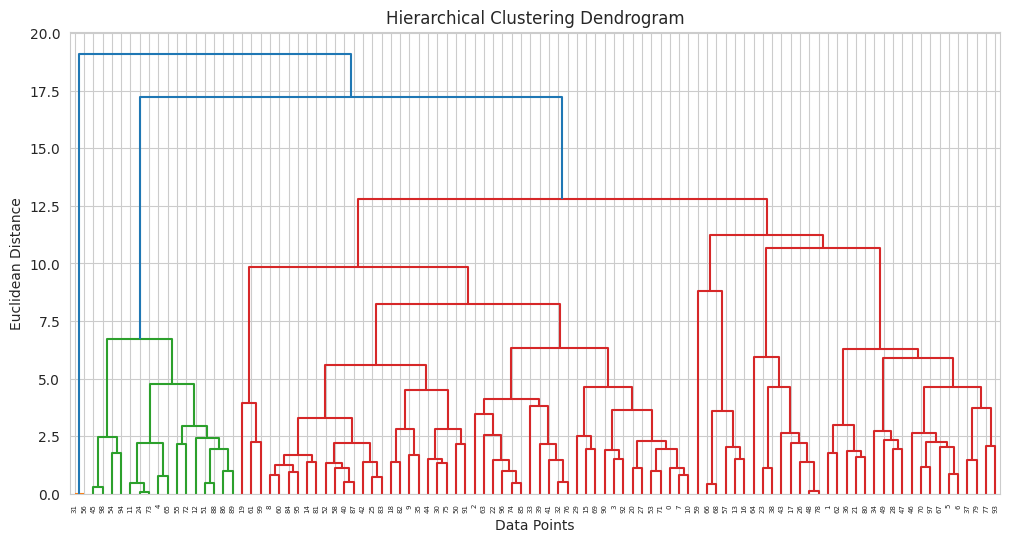

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_train[:100], method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

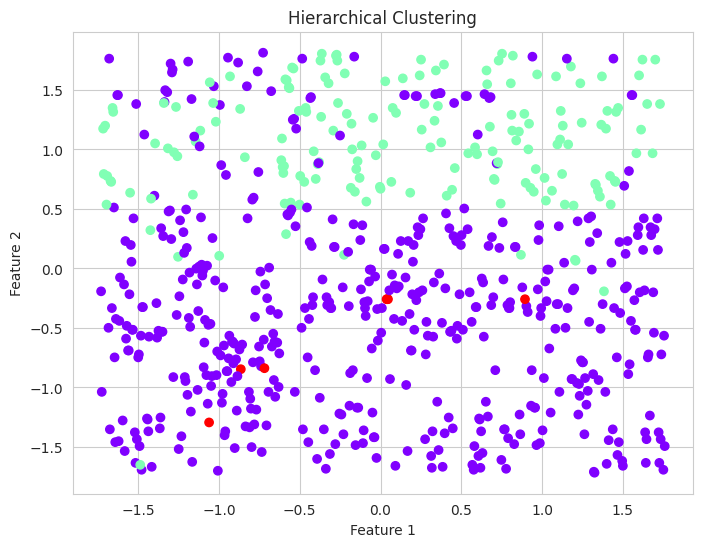

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], c=hc_labels, cmap='rainbow')
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

K means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(X_train)

print("Silhouette Score:", silhouette_score(X_train, kmeans_labels))

Silhouette Score: 0.17393921651360802


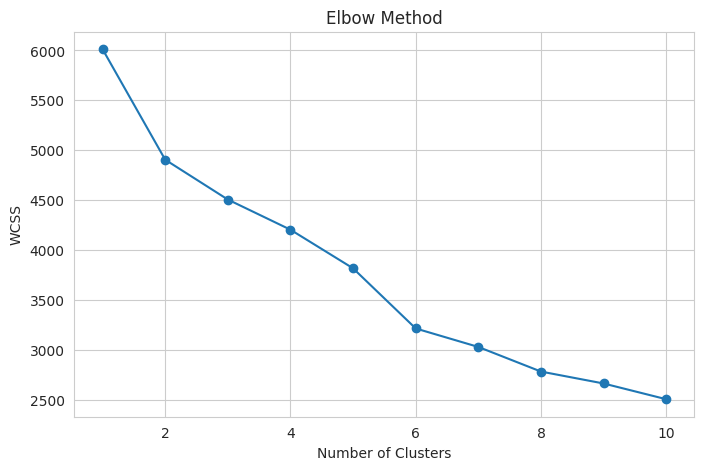

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_train)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

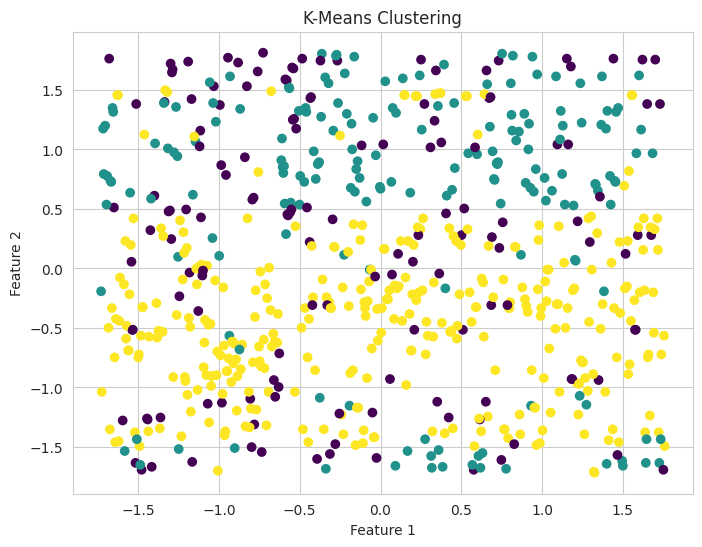

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

12.CLUSTER COMPARISON

In [ ]:
kmeans_score = silhouette_score(X_train, kmeans_labels)
hierarchical_score = silhouette_score(X_train, hc_labels)

print("K-Means Silhouette Score :", kmeans_score)
print("Hierarchical Silhouette Score :", hierarchical_score)

K-Means Silhouette Score : 0.17393921651360802
Hierarchical Silhouette Score : 0.21084937733968429


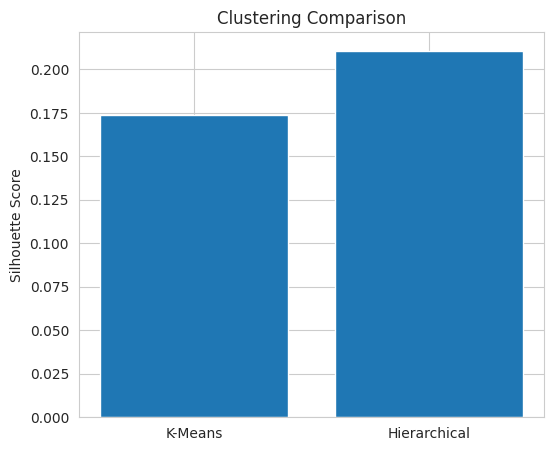

In [ ]:
models = ["K-Means","Hierarchical"]
scores = [kmeans_score, hierarchical_score]

plt.figure(figsize=(6,5))
plt.bar(models, scores)
plt.ylabel("Silhouette Score")
plt.title("Clustering Comparison")
plt.show()

**Conclusion:**

This project successfully predicted smartphone prices using hardware specifications. Gradient Boosting Regressor achieved the best prediction accuracy. Both K-Means and Hierarchical Clustering were applied, and Hierarchical Clustering produced more detailed market segment group